# dataset description
## informality by gender
**source**: dane

**dataset**: [empleo informal y seguridad social](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/empleo-informal-y-seguridad-social)

[Demografia y poblacion](https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion)

# code
## imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

pd.set_option("display.float_format", lambda x: "%.0f" % x)

## load data

In [2]:
path = "./data/sexo.csv"
path_2 = "./data/nacional.csv"

df = pd.read_csv(path, encoding="utf-8")
df_population = pd.read_csv(path_2, encoding="utf-8")

## Clean data
### Informality

In [3]:
df_2026 = df[
    (df["Fecha"].eq(2026)) &
    (df["Perspectiva"].eq("Total nacional")) &
    (df["Periodo"].eq("Feb - Abr")) &
    (df["Concepto"].eq("Población ocupada"))
].copy()

formal_informal = df_2026.groupby("Sexo")["Valor"].sum().mul(1000)
women_working_pct = formal_informal["Mujeres"] / formal_informal["Total"] * 100

### Population

In [4]:
population_2026 = df_population[df_population["AÑO"].eq(2026)]

def work_age_population(df, prefix):
    cols = df.loc[:, df.columns.str.startswith(f"{prefix}_")].copy()
    cols.columns = cols.columns.str.split("_").str[1].astype(int)
    return cols.loc[:, cols.columns >= 15]

women_population_26 = work_age_population(population_2026, "Mujeres")
men_population_26 = work_age_population(population_2026, "Hombres")
total_population_26 = work_age_population(population_2026, "Total")

women_work = women_population_26.sum(axis=1)
men_work = men_population_26.sum(axis=1)
total_work = total_population_26.sum(axis=1)

women_pct = women_work / total_work * 100
men_pct = men_work / total_work * 100

## Plot

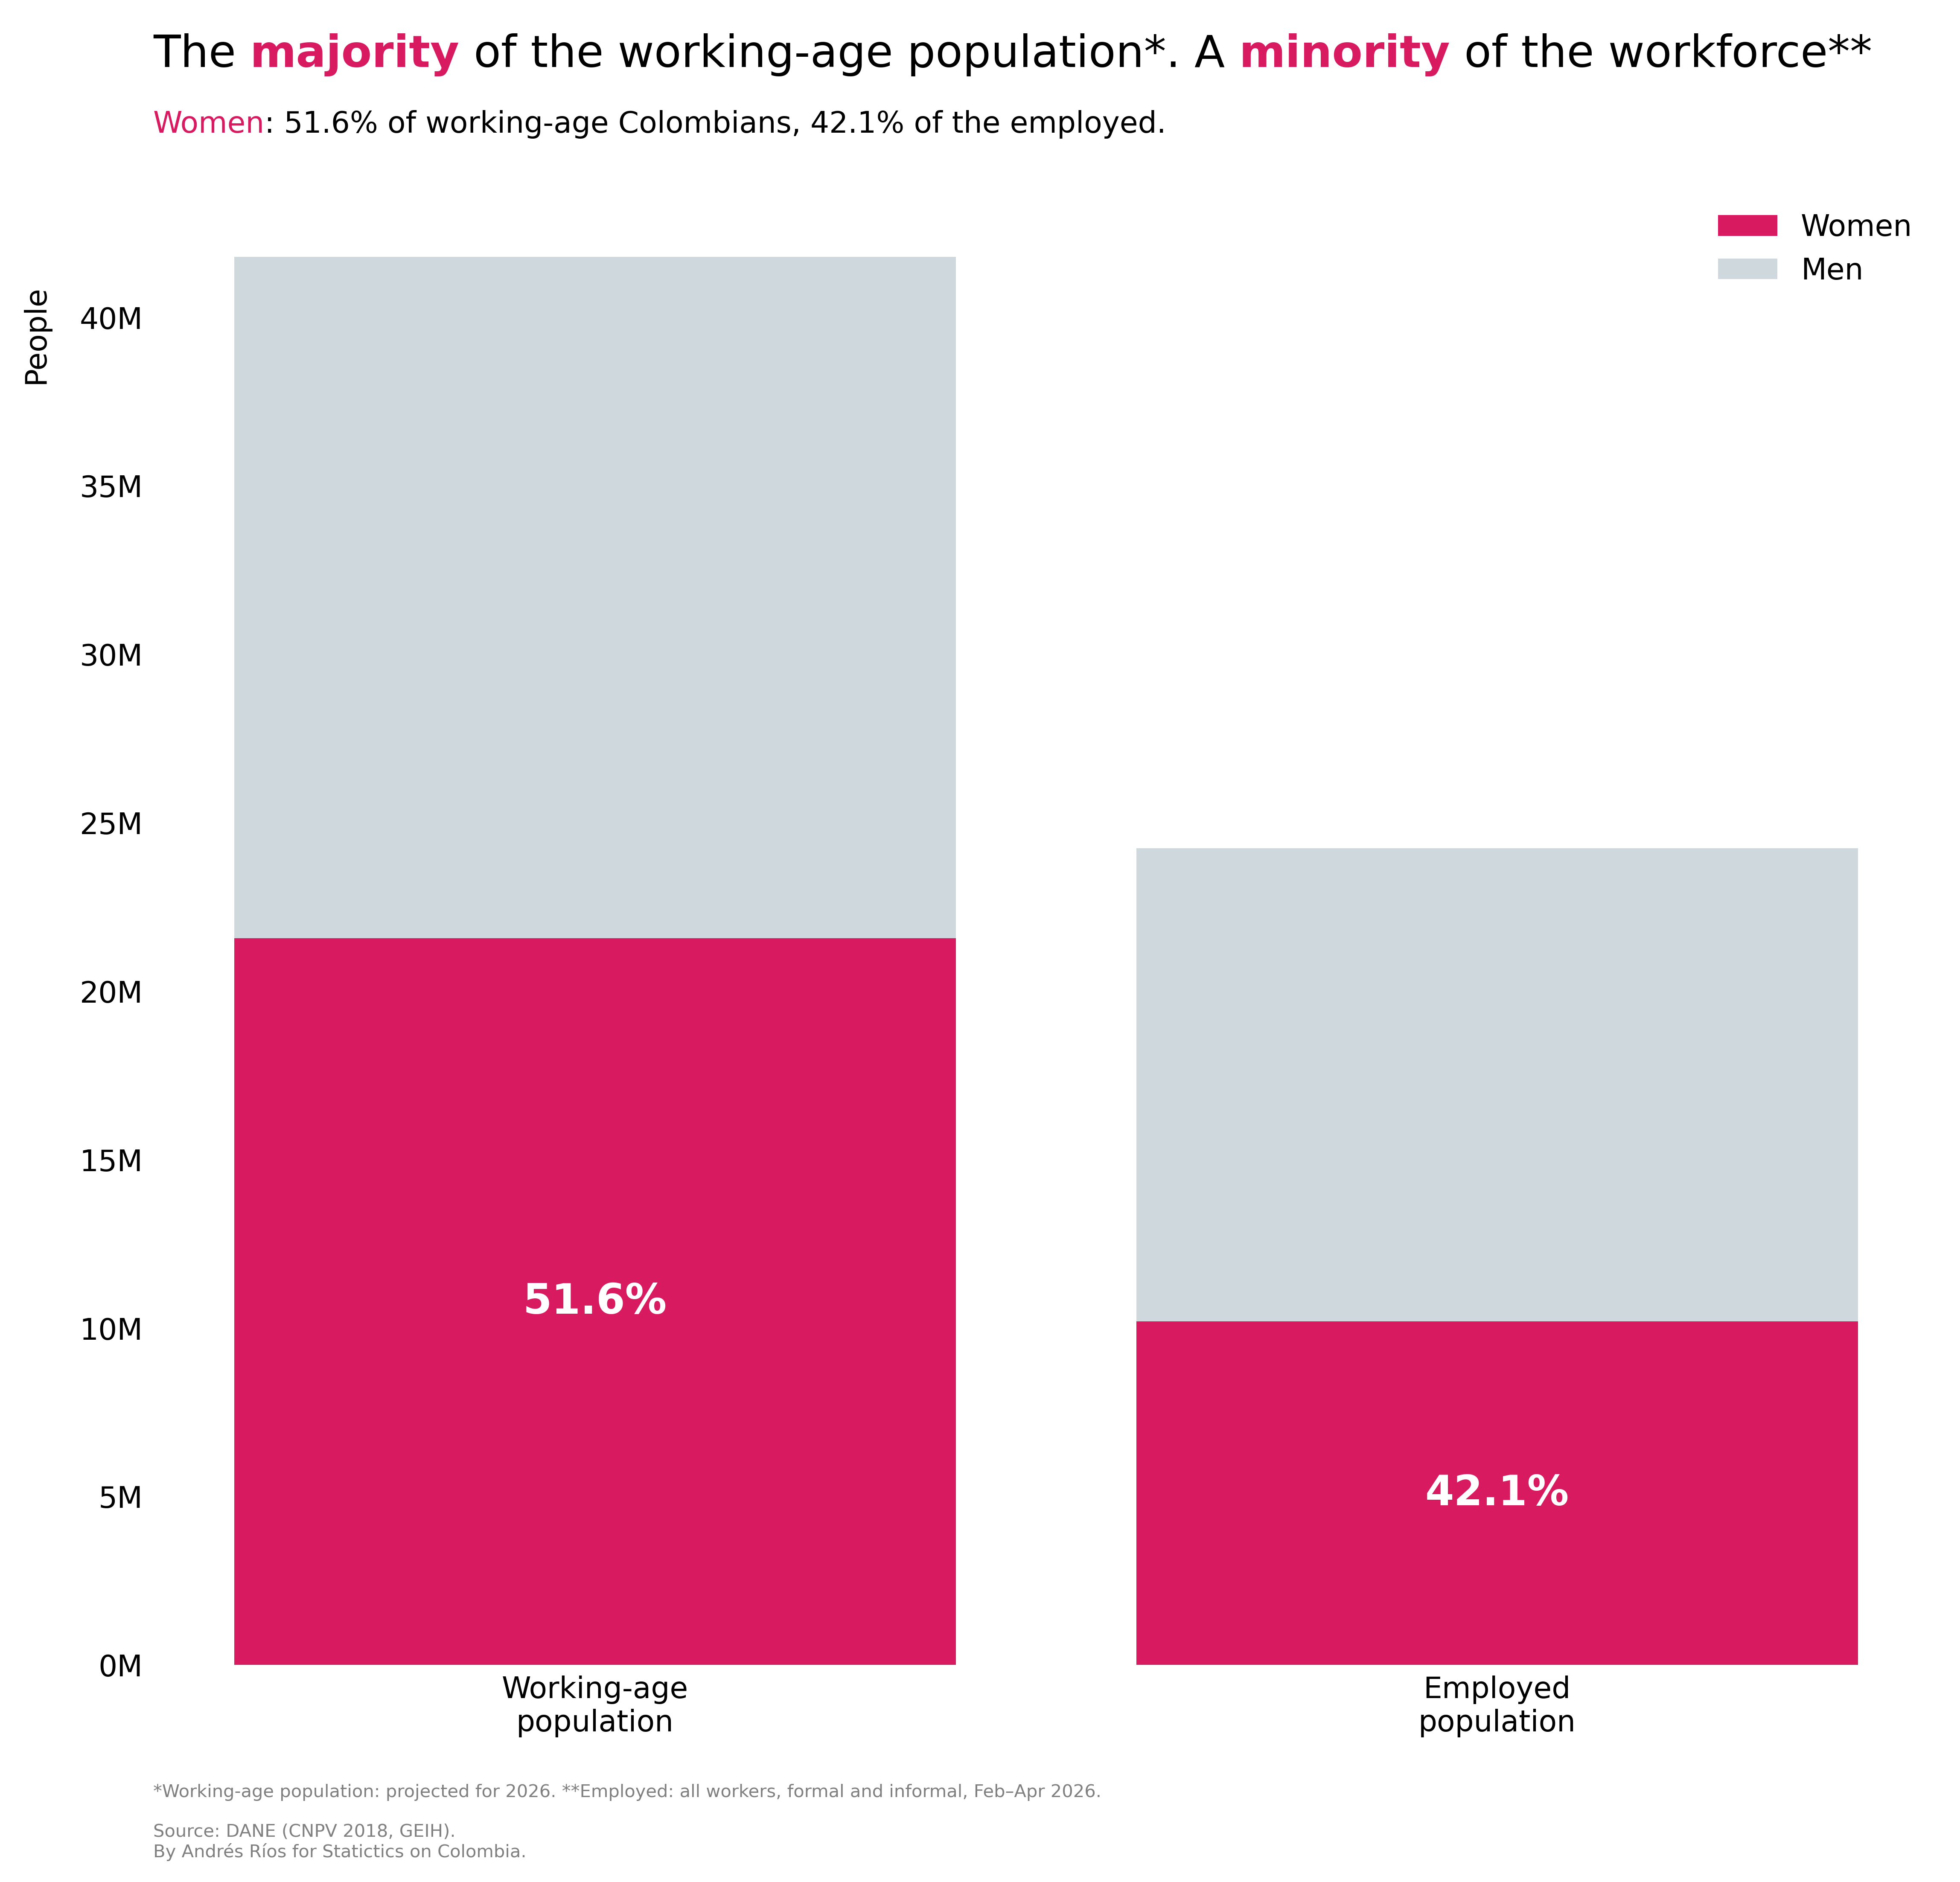

In [5]:
women_age = women_work.iloc[0]
men_age   = men_work.iloc[0]
women_emp = formal_informal["Mujeres"]
men_emp   = formal_informal["Hombres"]

women_age_share = women_pct.iloc[0]
women_emp_share = women_working_pct

labels    = ["Working-age\npopulation", "Employed\npopulation"]
women_vals = [women_age, women_emp]
men_vals   = [men_age, men_emp]
women_shares = [women_age_share, women_emp_share]

women_color = "#d81b60"   
men_color   = "#cfd8dc"   

plt.figure(figsize=(10.8, 9), dpi=500)

plt.bar(labels, women_vals, color=women_color, label="Women")
plt.bar(labels, men_vals, bottom=women_vals, color=men_color, label="Men")

for i, (w, pct) in enumerate(zip(women_vals, women_shares)):
    plt.text(i, w / 2, f"{pct:.1f}%", ha="center", va="center",
             color="white", fontweight="bold", fontsize=14)

for side in ["top", "left", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)
for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))

plt.ylabel("People", labelpad=10, y=0.9)
plt.legend(frameon=False, loc="upper right")

fig_text(
    0.125, 0.96,
    "The <majority> of the working-age population*. A <minority> of the workforce**",
    highlight_textprops=[{"color": women_color, "weight": "bold"},
                         {"color": women_color, "weight": "bold"}],
    fontsize=15,
)

fig_text(
    0.125, 0.92,
    "<Women>: 51.6% of working-age Colombians, 42.1% of the employed.",
    highlight_textprops=[{"color": women_color}],
    fontsize=10,
)

fig = plt.gcf()
fig.text(
    0.125, 0.01, 
    "*Working-age population: projected for 2026. "
    "**Employed: all workers, formal and informal, Feb–Apr 2026.\n\n"
    "Source: DANE (CNPV 2018, GEIH).\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=6, color="gray")

plt.show()